In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(
    r"C:\Users\guntu\OneDrive\Desktop\sales-forecasting-dashboard\data\Sample - Superstore.csv",
    encoding="latin1"
)


In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [8]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [9]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [10]:
df[['Order Date', 'Year', 'Month']].head()

,Order Date,Year,Month
0,2016-11-08,2016,11
1,2016-11-08,2016,11
2,2016-06-12,2016,6
3,2015-10-11,2015,10
4,2015-10-11,2015,10


In [11]:
monthly_sales = (
    df
    .groupby(pd.Grouper(key='Order Date', freq='M'))['Sales']
    .sum()
    .reset_index()
)

C:\Users\guntu\AppData\Local\Temp\ipykernel_25664\1786519947.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key='Order Date', freq='M'))['Sales']


In [12]:
monthly_sales.columns = ['ds', 'y']

In [13]:
monthly_sales.head()
monthly_sales.tail()

,ds,y
43,2017-08-31,63120.8880
44,2017-09-30,87866.6520
45,2017-10-31,77776.9232
46,2017-11-30,118447.8250
47,2017-12-31,83829.3188


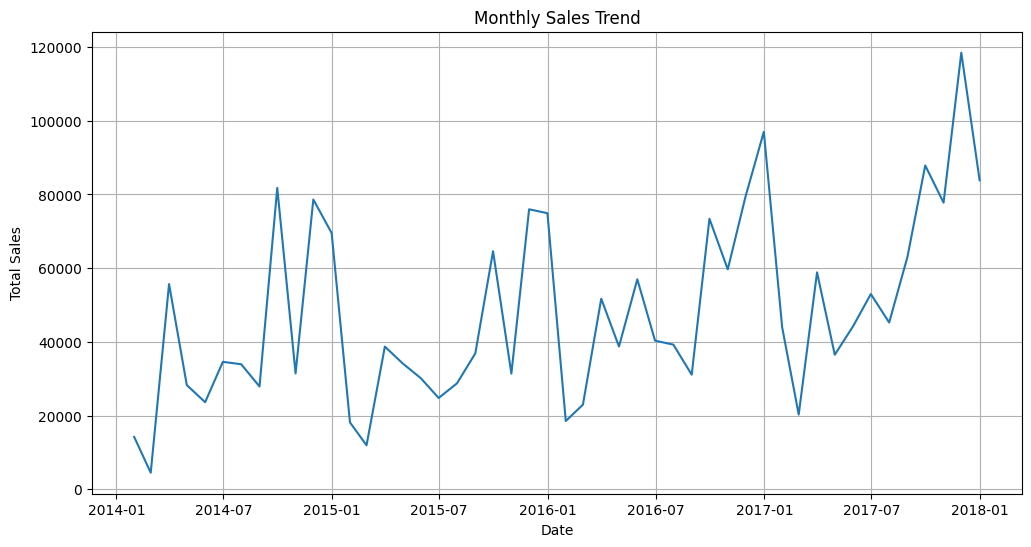

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['ds'], monthly_sales['y'])
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [15]:
monthly_sales['Month'] = monthly_sales['ds'].dt.month
monthly_sales['Year'] = monthly_sales['ds'].dt.year

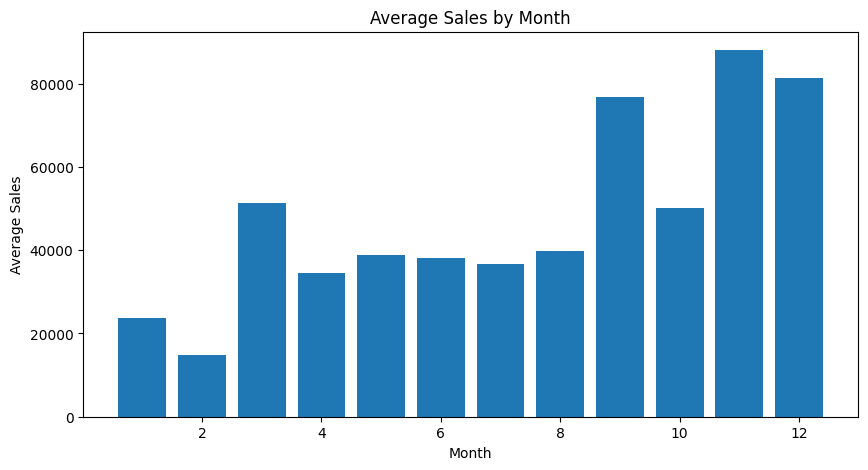

In [16]:
monthly_avg = monthly_sales.groupby('Month')['y'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(monthly_avg['Month'], monthly_avg['y'])
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()

In [17]:
from prophet import Prophet

C:\Users\guntu\OneDrive\Desktop\sales-forecasting-dashboard\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [18]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

In [19]:
model.fit(monthly_sales)

19:06:27 - cmdstanpy - INFO - Chain [1] start processing
19:06:28 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
future = model.make_future_dataframe(periods=6, freq='M')

C:\Users\guntu\OneDrive\Desktop\sales-forecasting-dashboard\venv\lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [21]:
future.tail()

,ds
49,2018-02-28
50,2018-03-31
51,2018-04-30
52,2018-05-31
53,2018-06-30


In [22]:
forecast = model.predict(future)

In [23]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
49,2018-02-28,35661.188232,26314.710878,45754.014954
50,2018-03-31,71959.640532,62820.098149,81018.574277
51,2018-04-30,55942.164642,46323.064824,64770.974665
52,2018-05-31,56193.017015,46570.955365,65280.146432
53,2018-06-30,57387.968259,48618.729024,66282.725863


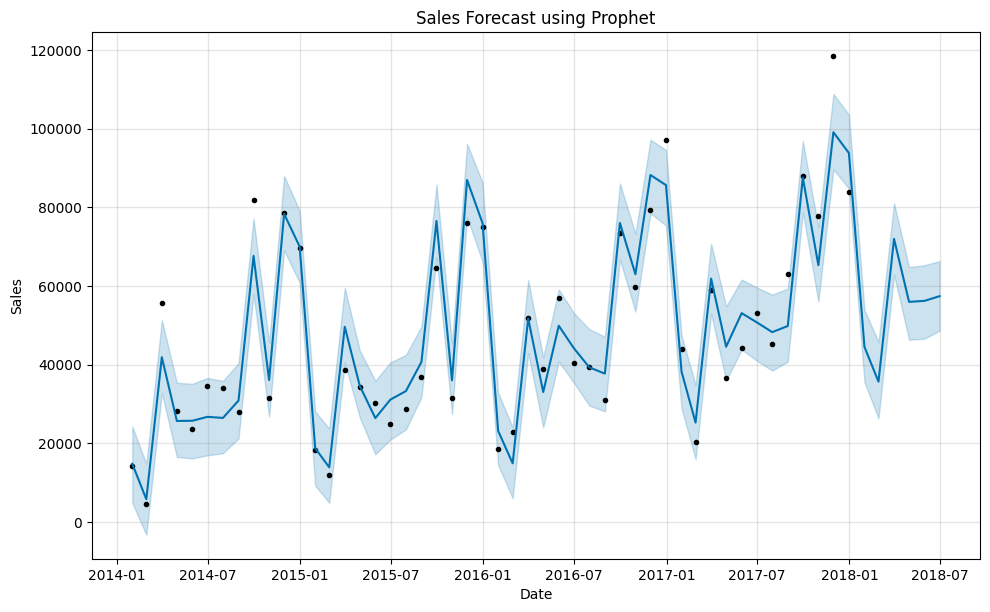

In [24]:
fig1 = model.plot(forecast)
plt.title("Sales Forecast using Prophet")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

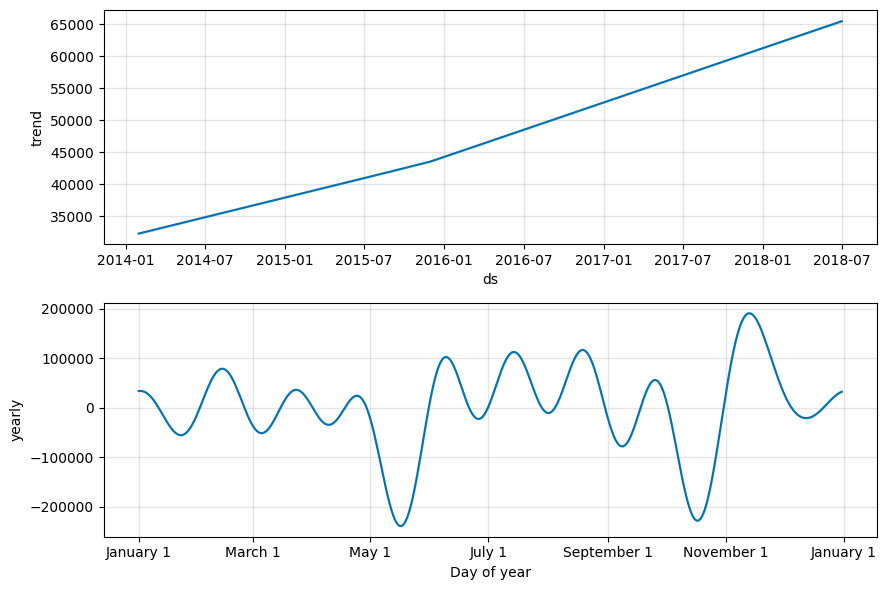

In [25]:
fig2 = model.plot_components(forecast)
plt.show()

In [26]:
final_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

In [27]:
final_forecast.columns = [
    'Date',
    'Forecasted Sales',
    'Lower Bound',
    'Upper Bound'
]

In [28]:
final_forecast.head()

,Date,Forecasted Sales,Lower Bound,Upper Bound
0,2014-01-31,14790.563637,4798.396233,24238.133591
1,2014-02-28,5778.538305,-3267.375648,14802.585277
2,2014-03-31,41875.343141,32752.233671,51266.416822
3,2014-04-30,25662.724545,16489.455070,35378.256991
4,2014-05-31,25711.929456,16153.043853,35114.164518


In [29]:
final_forecast.to_csv("../outputs/sales_forecast.csv", index=False)

In [30]:
import os
os.listdir("../outputs")

['sales_forecast.csv']

In [32]:
historical = monthly_sales[['ds', 'y']].copy()
historical.columns = ['Date', 'Actual Sales']

In [33]:
historical.to_csv("../outputs/historical_monthly_sales.csv", index=False)

In [34]:
import os
os.listdir("../outputs")

['historical_monthly_sales.csv', 'sales_forecast.csv']

In [36]:
df.shape

(9994, 23)

In [37]:
monthly_sales['ds'].min(), monthly_sales['ds'].max()


(Timestamp('2014-01-31 00:00:00'), Timestamp('2017-12-31 00:00:00'))

In [38]:
historical['Actual Sales'].sum()


np.float64(2297200.8603)

In [39]:
final_forecast[['Forecasted Sales']].describe()


,Forecasted Sales
count,54.000000
mean,48497.103847
std,23018.723216
min,5778.538305
25%,31568.513949
50%,44513.527143
75%,64692.260017
max,99056.321099


In [40]:
final_forecast.loc[
    final_forecast['Forecasted Sales'].idxmax()
]


Date                2017-11-30 00:00:00
Forecasted Sales           99056.321099
Lower Bound                 89610.03197
Upper Bound               108784.435549
Name: 46, dtype: object